In [10]:
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from time import time, gmtime, strftime


In [11]:
Data = pd.read_csv(r"Datos/pulsar_data_train.csv")
Data.head()



,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


In [12]:
# Verificamos si hay NaNs en el DataFrame
print("Cantidad de NaNs en cada columna:")
print(Data.isna().sum())
# Verificamos la proporción de NaNs en cada columna
print("Proporción de NaNs en cada columna:")
print(Data.isna().mean())
# Como se ve en el output la proporción de NaNs es baja entonces decidimos
# Eliminamos las filas con NaNs
Data = Data.dropna()

# Separo X de y
X=Data.drop(['target_class'], axis=1)
y=Data['target_class']



Cantidad de NaNs en cada columna:
 Mean of the integrated profile                     0
 Standard deviation of the integrated profile       0
 Excess kurtosis of the integrated profile       1735
 Skewness of the integrated profile                 0
 Mean of the DM-SNR curve                           0
 Standard deviation of the DM-SNR curve          1178
 Excess kurtosis of the DM-SNR curve                0
 Skewness of the DM-SNR curve                     625
target_class                                        0
dtype: int64
Proporción de NaNs en cada columna:
 Mean of the integrated profile                  0.000000
 Standard deviation of the integrated profile    0.000000
 Excess kurtosis of the integrated profile       0.138490
 Skewness of the integrated profile              0.000000
 Mean of the DM-SNR curve                        0.000000
 Standard deviation of the DM-SNR curve          0.094029
 Excess kurtosis of the DM-SNR curve             0.000000
 Skewness of the DM-SNR c

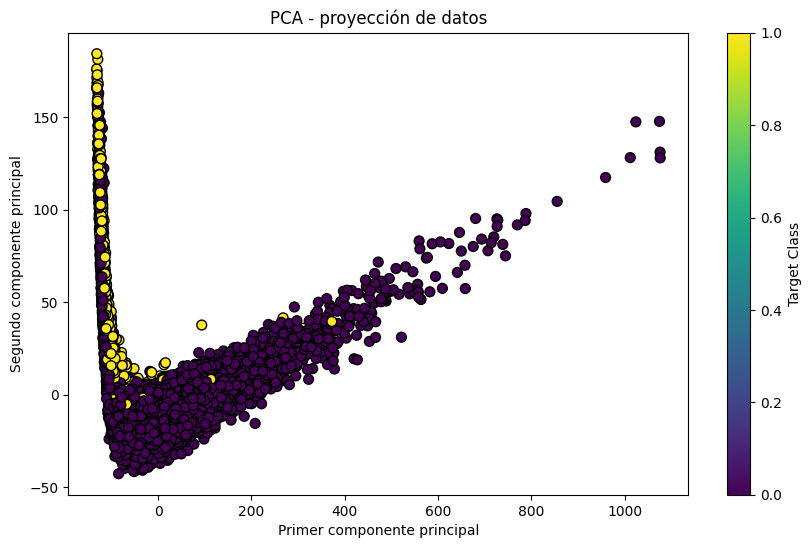

In [13]:
# Descomponemos por PCA para luego graficar y ver cómo se separan las clases
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# Graficamos los datos
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.title('PCA - proyección de datos')
plt.xlabel('Primer componente principal')
plt.ylabel('Segundo componente principal')
plt.colorbar(label='Target Class')
plt.show()

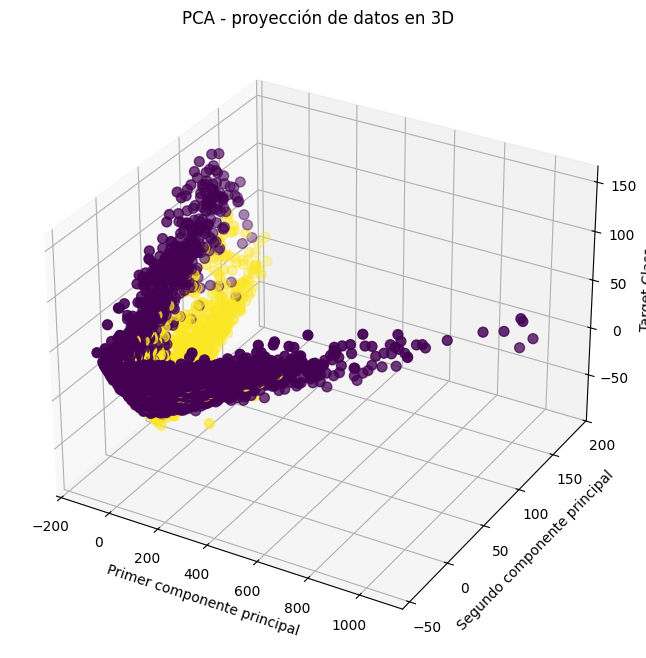

In [14]:
# Graficamos en tres dimensiones para ver cómo se separan las clases
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap='viridis', s=50)
ax.set_title('PCA - proyección de datos en 3D')
ax.set_xlabel('Primer componente principal')
ax.set_ylabel('Segundo componente principal')
ax.set_zlabel('Target Class')
plt.show()

Esto tiene pinta de separarse linealmente

In [15]:
# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


t=0.10, Precisión test: 0.9795148247978437
t=0.15, Precisión test: 0.9800539083557952
t=0.19, Precisión test: 0.9795148247978437
t=0.24, Precisión test: 0.9795148247978437
t=0.29, Precisión test: 0.9795148247978437
t=0.34, Precisión test: 0.9800539083557952
t=0.38, Precisión test: 0.9800539083557952
t=0.43, Precisión test: 0.9800539083557952
t=0.48, Precisión test: 0.9800539083557952
t=0.53, Precisión test: 0.9800539083557952
t=0.57, Precisión test: 0.9805929919137466
t=0.62, Precisión test: 0.9805929919137466
t=0.67, Precisión test: 0.9805929919137466
t=0.72, Precisión test: 0.9805929919137466
t=0.76, Precisión test: 0.9805929919137466
t=0.81, Precisión test: 0.9805929919137466
t=0.86, Precisión test: 0.9805929919137466
t=0.91, Precisión test: 0.9805929919137466
t=0.95, Precisión test: 0.9805929919137466
t=1.00, Precisión test: 0.9805929919137466


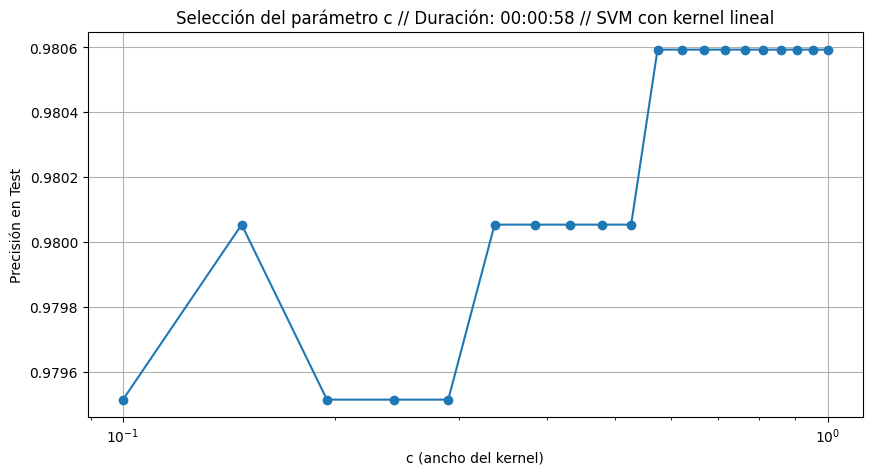

In [16]:
# SVM con kernel lineal
# Evaluación de parámetros c
c_values = np.linspace(0.1, 1.0, 20)
test_scores = []


initial_time=time()
test_scores=[]
for c in c_values:
    clf = svm.SVC(kernel='linear',C=c)
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    test_scores.append(score)
    print(f"t={c:.2f}, Precisión test: {score}")

# Guardamos los resultados para el gráfico final de comparación
test_scores_df = pd.DataFrame(test_scores, index=c_values, columns=['lineal'])

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(c_values, test_scores, 'o-')
plt.xscale('log')
plt.xlabel('c (ancho del kernel)')
plt.ylabel('Precisión en Test')
duracion=gmtime(time()-initial_time)
plt.title(f'Selección del parámetro c // Duración: {strftime("%H:%M:%S", duracion)} // SVM con kernel lineal')
plt.grid(True)
plt.show()

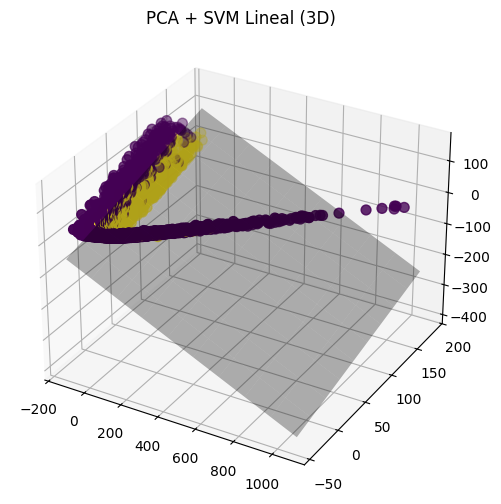

In [17]:
# Graficamos la frontera de decisión en 3D con PCA y SVM Lineal
# 1: Entrenamos SVM con 3D PCA data
clf.fit(X_pca, y)

# 2: 3D Plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap='viridis', s=50)

# 3: Frontera de decisión
x_min, x_max = X_pca[:, 0].min(), X_pca[:, 0].max()
y_min, y_max = X_pca[:, 1].min(), X_pca[:, 1].max()
z_min, z_max = X_pca[:, 2].min(), X_pca[:, 2].max()

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(y_min, y_max, 10))
zz = (-clf.intercept_[0] - clf.coef_[0][0] * xx - clf.coef_[0][1] * yy) / clf.coef_[0][2]
ax.plot_surface(xx, yy, zz, alpha=0.3, color='k')

plt.title('PCA + SVM Lineal (3D)')
plt.show()

No se ve tan bien como esperabamos pero el accuracy es alto, lo que nos dice que éste modelo SVM lineal funciona muy bien.

Como vimos en clase vamos a aplicar una transformación polinómica para ver como se ven los datos

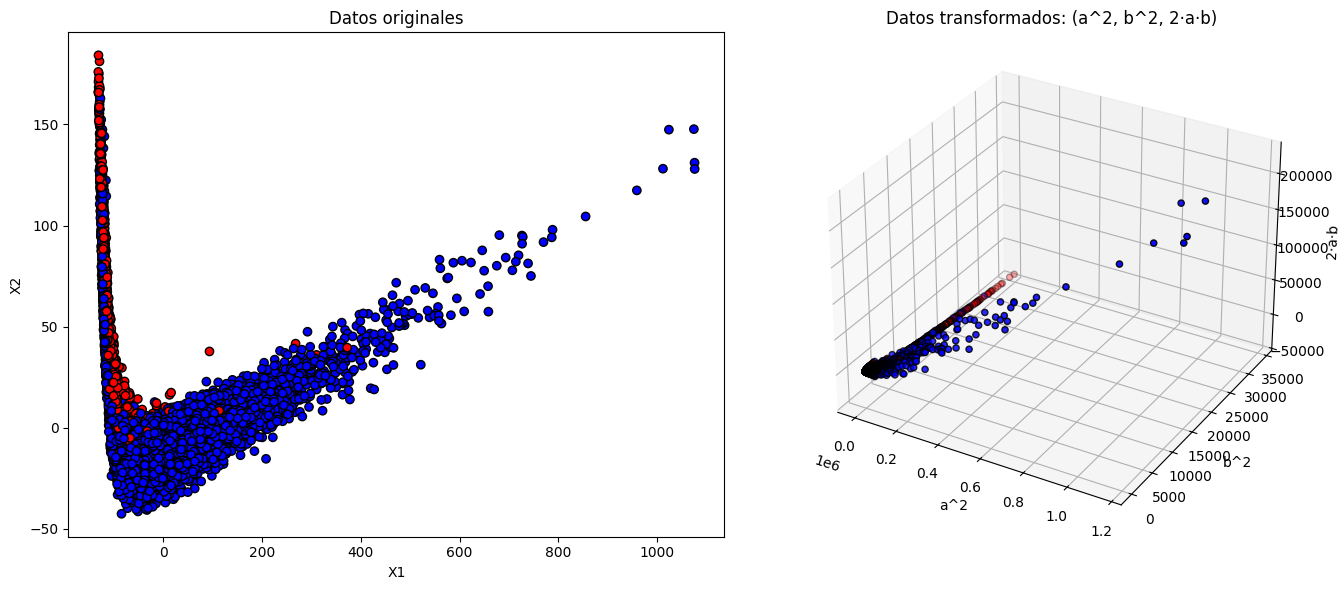

In [18]:
# volvemos a dos componentes de PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# Aplicamos la transformación polinómica: (a,b) -> (a^2, b^2, sqrt(2)*a*b)
X_poly = np.zeros((X.shape[0], 3))
X_poly[:, 0] = X_pca[:, 0] ** 2 # a^2
X_poly[:, 1] = X_pca[:, 1] ** 2 # b^2
X_poly[:, 2] = np.sqrt(2) * X_pca[:, 0] * X_pca[:, 1] # sqrt(2) * a * b
# Configuramos la figura con dos subgráficos
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.title("Datos originales")
plt.xlabel("X1")
plt.ylabel("X2")
# Gráfico 2: Datos transformados en 3D
ax = plt.subplot(1, 2, 2, projection='3d')
ax.scatter(X_poly[:, 0], X_poly[:, 1], X_poly[:, 2], c=y,
cmap='bwr', edgecolor='k')
ax.set_title("Datos transformados: (a^2, b^2, 2·a·b)")
ax.set_xlabel("a^2")
ax.set_ylabel("b^2")
ax.set_zlabel("2·a·b")

plt.tight_layout()
plt.show()



Como se puede ver es todavía mas HORRIBLE

t=0.10, Precisión test: 0.9730458221024259
t=0.15, Precisión test: 0.9752021563342318
t=0.19, Precisión test: 0.9757412398921833
t=0.24, Precisión test: 0.9757412398921833
t=0.29, Precisión test: 0.9757412398921833
t=0.34, Precisión test: 0.9757412398921833
t=0.38, Precisión test: 0.9757412398921833
t=0.43, Precisión test: 0.9762803234501348
t=0.48, Precisión test: 0.9762803234501348
t=0.53, Precisión test: 0.9762803234501348
t=0.57, Precisión test: 0.9762803234501348
t=0.62, Precisión test: 0.9762803234501348
t=0.67, Precisión test: 0.9762803234501348
t=0.72, Precisión test: 0.9762803234501348
t=0.76, Precisión test: 0.9762803234501348
t=0.81, Precisión test: 0.9762803234501348
t=0.86, Precisión test: 0.9762803234501348
t=0.91, Precisión test: 0.9762803234501348
t=0.95, Precisión test: 0.9762803234501348
t=1.00, Precisión test: 0.9768194070080862


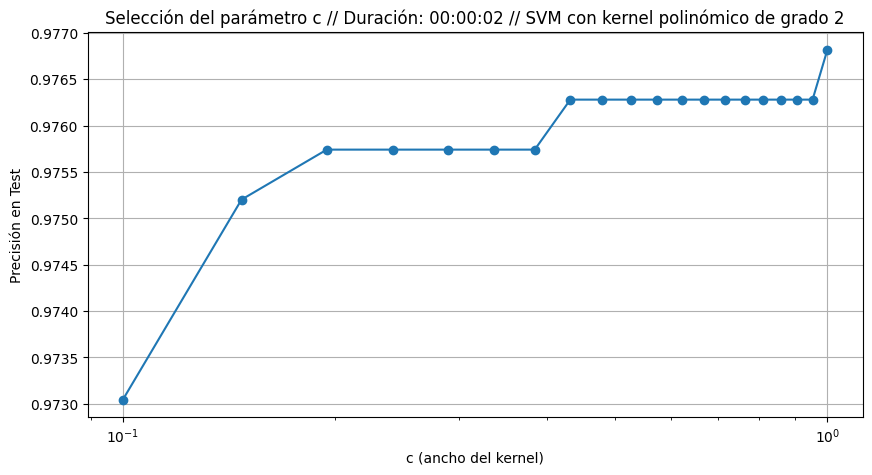

In [19]:
# SVM con kernel polinómico grado 2
# Evaluación de parámetros c
c_values = np.linspace(0.1, 1.0, 20)
test_scores = []


initial_time=time()
test_scores=[]
for c in c_values:
    clf = svm.SVC(kernel='poly',degree=2,C=c)
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    test_scores.append(score)
    print(f"t={c:.2f}, Precisión test: {score}")

# Guardamos los resultados para el gráfico final de comparación
test_scores_df['polinomico'] = test_scores

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(c_values, test_scores, 'o-')
plt.xscale('log')
plt.xlabel('c (ancho del kernel)')
plt.ylabel('Precisión en Test')
duracion=gmtime(time()-initial_time)
plt.title(f'Selección del parámetro c // Duración: {strftime("%H:%M:%S", duracion)} // SVM con kernel polinómico de grado 2')
plt.grid(True)
plt.show()

t=0.10, Precisión test: 0.9730458221024259
t=0.15, Precisión test: 0.9741239892183289
t=0.19, Precisión test: 0.9757412398921833
t=0.24, Precisión test: 0.9757412398921833
t=0.29, Precisión test: 0.9757412398921833
t=0.34, Precisión test: 0.9757412398921833
t=0.38, Precisión test: 0.9762803234501348
t=0.43, Precisión test: 0.9762803234501348
t=0.48, Precisión test: 0.9762803234501348
t=0.53, Precisión test: 0.9762803234501348
t=0.57, Precisión test: 0.9762803234501348
t=0.62, Precisión test: 0.9762803234501348
t=0.67, Precisión test: 0.9762803234501348
t=0.72, Precisión test: 0.9762803234501348
t=0.76, Precisión test: 0.9762803234501348
t=0.81, Precisión test: 0.9762803234501348
t=0.86, Precisión test: 0.9762803234501348
t=0.91, Precisión test: 0.9762803234501348
t=0.95, Precisión test: 0.9762803234501348
t=1.00, Precisión test: 0.9762803234501348


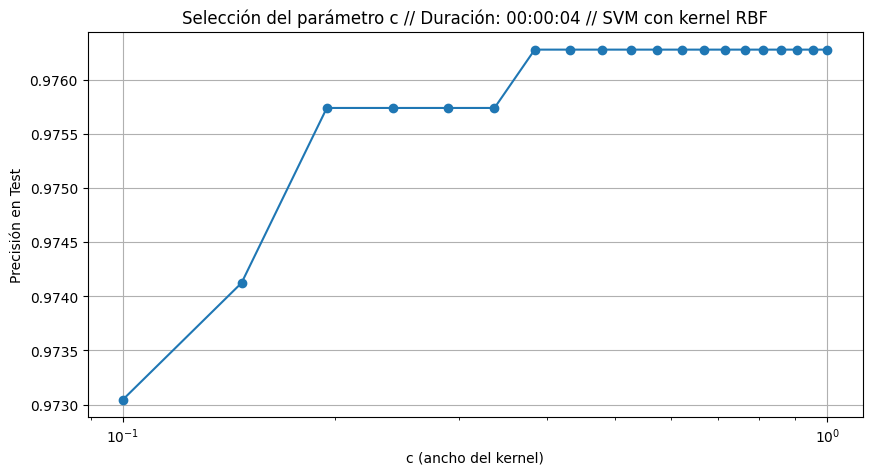

In [20]:
# SVM con kernel rbf grado 2
# Evaluación de parámetros c
c_values = np.linspace(0.1, 1.0, 20)
test_scores = []


initial_time=time()
test_scores=[]
for c in c_values:
    clf = svm.SVC(kernel='rbf',C=c)
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    test_scores.append(score)
    print(f"t={c:.2f}, Precisión test: {score}")

# Guardamos los resultados para el gráfico final de comparación
test_scores_df['rbf'] = test_scores

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(c_values, test_scores, 'o-')
plt.xscale('log')
plt.xlabel('c (ancho del kernel)')
plt.ylabel('Precisión en Test')
duracion=gmtime(time()-initial_time)
plt.title(f'Selección del parámetro c // Duración: {strftime("%H:%M:%S", duracion)} // SVM con kernel RBF')
plt.grid(True)
plt.show()


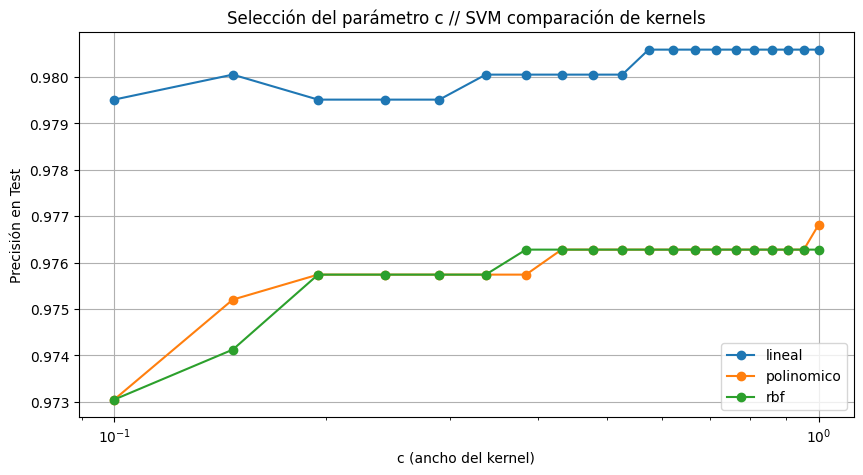

In [21]:
# Gráfico de comparación
plt.figure(figsize=(10, 5))
plt.plot(c_values, test_scores_df, 'o-')
plt.legend(test_scores_df.columns)
plt.xscale('log')
plt.xlabel('c (ancho del kernel)')
plt.ylabel('Precisión en Test')

plt.title(f'Selección del parámetro c // SVM comparación de kernels')
plt.grid(True)
plt.show()

Como pensabamos el kernel lineal separa bastante bien en comparación a los otros.